In [1]:
# =========================================================
# CELL 1 — IMPORTS + GLOBAL SETUP (CLEAN)
# =========================================================

# ------------------ CORE ------------------
import os
import random
import numpy as np

# ------------------ TORCH ------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ------------------ VISION ------------------
from PIL import Image
from torchvision import transforms as T

# ------------------ LIGHTNING ------------------
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning import loggers as pl_loggers
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor

# ------------------ MODEL UTILS ------------------
from segmentation_models_pytorch.encoders import get_encoder
from segmentation_models_pytorch.base import SegmentationModel

# ------------------ METRICS / HELPERS ------------------
import matplotlib.pyplot as plt

# (we will define these later properly)
# from evaluate.utils import recompone_overlap, metric_calculate
# from util.utils import DiceLoss, sigmoid_mse_loss, get_current_consistency_weight

# =========================================================
# SEED (VERY IMPORTANT FOR REPRODUCIBILITY)
# =========================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

# =========================================================
# DEVICE
# =========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# =========================================================
# BASIC CONFIG (WE WILL EXPAND LATER)
# =========================================================

IMG_SIZE = 384        # paper uses 384
BATCH_SIZE = 8
L_BATCH_SIZE = 4      # labeled portion
U_BATCH_SIZE = BATCH_SIZE - L_BATCH_SIZE

MAX_EPOCHS = 50
LR = 3e-4
EMA_ALPHA = 0.99
T_SAMPLES = 10
BETA = 0.75

print("\nConfig Loaded")

/home/ayushp/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda

Config Loaded


In [2]:
# =========================================================
# CELL 2 — DATA PATHS + FILE LISTS (ID-BASED SPLIT)
# =========================================================

import os
import random

# ------------------ BASE DIRECTORIES ------------------
BASE_DIR = "/home/ayushp/Caries_Detection"
DC1000_DIR = "/home/ayushp/DC1000_dataset"

# ------------------ LABELED TRAIN DATA ------------------
TRAIN_IMG_DIR  = os.path.join(BASE_DIR, "images")
TRAIN_MASK_DIR = os.path.join(BASE_DIR, "masks")

# ------------------ TEST DATA (ORG TEST DATASET) ------------------
TEST_IMG_DIR  = os.path.join(DC1000_DIR, "org_test_dataset", "images")
TEST_MASK_DIR = os.path.join(DC1000_DIR, "org_test_dataset", "labels")

# =========================================================
# CHECK PATHS
# =========================================================

print("\nChecking paths...\n")

paths = [
    TRAIN_IMG_DIR,
    TRAIN_MASK_DIR,
    TEST_IMG_DIR,
    TEST_MASK_DIR
]

for p in paths:
    print(f"{p} → {'Exists' if os.path.exists(p) else 'Not Found'}")

# =========================================================
# LOAD ALL FILES
# =========================================================

all_images = sorted([
    os.path.join(TRAIN_IMG_DIR, f)
    for f in os.listdir(TRAIN_IMG_DIR)
])

all_masks = sorted([
    os.path.join(TRAIN_MASK_DIR, f)
    for f in os.listdir(TRAIN_MASK_DIR)
])

assert len(all_images) == len(all_masks)

# =========================================================
# HELPER: EXTRACT IMAGE ID
# =========================================================

def get_id(path):
    return int(os.path.basename(path).split(".")[0])

# =========================================================
# VALIDATION SPLIT (FIRST 100 — FIXED)
# =========================================================

VAL_SIZE = 100

val_images = all_images[:VAL_SIZE]
val_masks  = all_masks[:VAL_SIZE]

remaining_images = all_images[VAL_SIZE:]
remaining_masks  = all_masks[VAL_SIZE:]

# =========================================================
# LABELED / UNLABELED SPLIT (ID BASED)
# =========================================================

train_images = []
train_masks = []
unlabeled_images = []

for img_path, mask_path in zip(remaining_images, remaining_masks):

    img_id = get_id(img_path)

    if img_id < 1558:
        train_images.append(img_path)
        train_masks.append(mask_path)
    else:
        unlabeled_images.append(img_path)

# =========================================================
# FINAL STATS
# =========================================================

print("\n===== FINAL DATA SPLIT =====")
print(f"Train Labeled     : {len(train_images)}")
print(f"Train Unlabeled   : {len(unlabeled_images)}")
print(f"Validation (100)  : {len(val_images)}")


Checking paths...

/home/ayushp/Caries_Detection/images → Exists
/home/ayushp/Caries_Detection/masks → Exists
/home/ayushp/DC1000_dataset/org_test_dataset/images → Exists
/home/ayushp/DC1000_dataset/org_test_dataset/labels → Exists

===== FINAL DATA SPLIT =====
Train Labeled     : 1360
Train Unlabeled   : 929
Validation (100)  : 100


In [3]:
# =========================================================
# CELL 3 — DATASETS (PAPER-ALIGNED)
# =========================================================

class TrainDataset(Dataset):
    def __init__(self, labeled_imgs, labeled_masks, unlabeled_imgs):
        
        self.labeled_imgs = labeled_imgs
        self.labeled_masks = labeled_masks
        self.unlabeled_imgs = unlabeled_imgs

        # Combine both (important for sampler)
        self.all_images = self.labeled_imgs + self.unlabeled_imgs

        # ------------------ TRANSFORMS ------------------
        self.img_transform = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
        ])

        self.resize = T.Resize((IMG_SIZE, IMG_SIZE))
        self.to_tensor = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.5], std=[0.5])
        ])

        print(f"Train Dataset Loaded: {len(self.all_images)} samples")

    def __len__(self):
        return len(self.all_images)

    def __getitem__(self, idx):

        # ------------------ LABELED ------------------
        if idx < len(self.labeled_imgs):

            img_path = self.labeled_imgs[idx]
            mask_path = self.labeled_masks[idx]

            img = Image.open(img_path).convert("L")
            mask = Image.open(mask_path)

            # SAME AUGMENTATION
            seed = random.randint(0, 10000)
            torch.manual_seed(seed)
            img = self.img_transform(img)

            torch.manual_seed(seed)
            mask = self.img_transform(mask)

            img = self.resize(img)
            mask = self.resize(mask)

            img = self.to_tensor(img)
            mask = self.to_tensor(mask)

            mask = (mask > 0).float()

            return img, mask

        # ------------------ UNLABELED ------------------
        else:

            img_path = self.unlabeled_imgs[idx - len(self.labeled_imgs)]

            img = Image.open(img_path).convert("L")

            img = self.img_transform(img)
            img = self.resize(img)
            img = self.to_tensor(img)

            # DUMMY MASK (important)
            mask = torch.zeros((1, IMG_SIZE, IMG_SIZE), dtype=torch.float32)

            return img, mask


# =========================================================
# VALIDATION DATASET (PANORAMA PATCH INPUT)
# =========================================================

class ValDataset(Dataset):
    def __init__(self, image_list, mask_list):

        self.image_list = image_list
        self.mask_list = mask_list

        self.resize = T.Resize((IMG_SIZE, IMG_SIZE))
        self.to_tensor = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.5], std=[0.5])
        ])

        print(f"Validation Dataset Loaded: {len(self.image_list)} images")

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):

        img = Image.open(self.image_list[idx]).convert("L")
        mask = Image.open(self.mask_list[idx])

        img = self.resize(img)
        mask = self.resize(mask)

        img = self.to_tensor(img)
        mask = self.to_tensor(mask)

        mask = (mask > 0).float()

        return img, mask

In [4]:
# =========================================================
# CELL 4 — DATALOADER + TWO STREAM SAMPLER (PAPER CORE)
# =========================================================

from torch.utils.data.sampler import Sampler
import itertools

# =========================================================
# TWO STREAM BATCH SAMPLER (CRITICAL)
# =========================================================

class TwoStreamBatchSampler(Sampler):
    """
    Iterates two sets of indices:
    - labeled indices
    - unlabeled indices

    Each batch = L labeled + U unlabeled
    """

    def __init__(self, labeled_idxs, unlabeled_idxs, batch_size, labeled_batch_size):
        self.labeled_idxs = labeled_idxs
        self.unlabeled_idxs = unlabeled_idxs
        self.labeled_batch_size = labeled_batch_size
        self.unlabeled_batch_size = batch_size - labeled_batch_size

    def __iter__(self):
        labeled_iter = self.shuffle_once(self.labeled_idxs)
        unlabeled_iter = self.shuffle_eternally(self.unlabeled_idxs)

        return (
            labeled_batch + unlabeled_batch
            for labeled_batch, unlabeled_batch in zip(
                self.grouper(labeled_iter, self.labeled_batch_size),
                self.grouper(unlabeled_iter, self.unlabeled_batch_size),
            )
        )

    def __len__(self):
        return len(self.labeled_idxs) // self.labeled_batch_size

    def shuffle_once(self, indices):
        return np.random.permutation(indices)

    def shuffle_eternally(self, indices):
        while True:
            yield from np.random.permutation(indices)

    def grouper(self, iterable, n):
        args = [iter(iterable)] * n
        return zip(*args)


# =========================================================
# CREATE DATASETS
# =========================================================

train_dataset = TrainDataset(train_images, train_masks, unlabeled_images)
val_dataset = ValDataset(val_images, val_masks)


# =========================================================
# CREATE SAMPLER INDICES
# =========================================================

total_size = len(train_dataset)
labeled_size = len(train_images)

print("\nSANITY CHECK:")
print(f"Labeled idx range: 0 → {len(train_images)-1}")
print(f"Unlabeled idx range: {len(train_images)} → {total_size-1}")

all_indices = list(range(total_size))

labeled_idxs = list(range(labeled_size))
unlabeled_idxs = list(range(labeled_size, total_size))


print("\nSampler Setup:")
print(f"Labeled samples   : {len(labeled_idxs)}")
print(f"Unlabeled samples : {len(unlabeled_idxs)}")

# =========================================================
# SAMPLER
# =========================================================

batch_sampler = TwoStreamBatchSampler(
    labeled_idxs,
    unlabeled_idxs,
    batch_size=BATCH_SIZE,
    labeled_batch_size=L_BATCH_SIZE
)

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_sampler=batch_sampler,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,   # IMPORTANT (paper requirement)
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

print("\nDataloaders Ready")

Train Dataset Loaded: 2289 samples
Validation Dataset Loaded: 100 images

SANITY CHECK:
Labeled idx range: 0 → 1359
Unlabeled idx range: 1360 → 2288

Sampler Setup:
Labeled samples   : 1360
Unlabeled samples : 929

Dataloaders Ready


In [ ]:
# =========================================================
# CELL 5 — MODEL (ATTENTION + DEEP SUPERVISION + IMPROVED FPN)
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from segmentation_models_pytorch.encoders import get_encoder


# =========================================================
# ATTENTION GATE
# =========================================================

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l):
        super().__init__()

        self.W_g = nn.Conv2d(F_g, F_l, kernel_size=1)
        self.W_x = nn.Conv2d(F_l, F_l, kernel_size=1)
        self.psi = nn.Conv2d(F_l, 1, kernel_size=1)

        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, g, x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.sigmoid(self.psi(psi))

        return x * psi


# =========================================================
# BASIC BLOCK
# =========================================================

class Conv3x3GNReLU(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.GroupNorm(32, out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


# =========================================================
# FPN BLOCK (WITH ATTENTION)
# =========================================================

class FPNBlock(nn.Module):
    def __init__(self, pyramid_channels, skip_channels, top_layer=False):
        super().__init__()
        self.top_layer = top_layer

        self.skip_conv = nn.Conv2d(skip_channels, pyramid_channels, kernel_size=1)

        if not top_layer:
            self.attention = AttentionGate(pyramid_channels, pyramid_channels)

    def forward(self, x, skip=None):

        if self.top_layer:
            return self.skip_conv(x)

        x = F.interpolate(x, scale_factor=2, mode="nearest")

        skip = self.skip_conv(skip)

        # Attention applied
        skip = self.attention(x, skip)

        return x + skip


# =========================================================
# SEGMENTATION BLOCK
# =========================================================

class SegmentationBlock(nn.Module):
    def __init__(self, in_channels, out_channels, n_upsamples=0):
        super().__init__()

        layers = []

        for i in range(n_upsamples):
            layers.append(Conv3x3GNReLU(in_channels if i == 0 else out_channels, out_channels))
            layers.append(nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True))

        if n_upsamples == 0:
            layers.append(Conv3x3GNReLU(in_channels, out_channels))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


# =========================================================
# IMPROVED MERGE (LEARNABLE WEIGHTS)
# =========================================================

class WeightedMergeBlock(nn.Module):
    def __init__(self, n_inputs=4):
        super().__init__()

        self.weights = nn.Parameter(torch.ones(n_inputs))

    def forward(self, features):

        w = torch.softmax(self.weights, dim=0)

        out = 0
        for i in range(len(features)):
            out += w[i] * features[i]

        return out


# =========================================================
# FPN DECODER (UPGRADED)
# =========================================================

class FPNDecoder(nn.Module):
    def __init__(self, encoder_channels, pyramid_channels=256, segmentation_channels=128):
        super().__init__()

        encoder_channels = encoder_channels[::-1]

        self.p5 = FPNBlock(pyramid_channels, encoder_channels[0], top_layer=True)
        self.p4 = FPNBlock(pyramid_channels, encoder_channels[1])
        self.p3 = FPNBlock(pyramid_channels, encoder_channels[2])
        self.p2 = FPNBlock(pyramid_channels, encoder_channels[3])

        self.seg_blocks = nn.ModuleList([
            SegmentationBlock(pyramid_channels, segmentation_channels, n_upsamples=n)
            for n in [3, 2, 1, 0]
        ])

        self.merge = WeightedMergeBlock(4)

        # FEATURE REFINEMENT (VERY IMPORTANT)
        self.refine = nn.Sequential(
            Conv3x3GNReLU(segmentation_channels, segmentation_channels),
            Conv3x3GNReLU(segmentation_channels, segmentation_channels)
        )

        self.dropout = nn.Dropout2d(0.3)

        self.out_channels = segmentation_channels

    def forward(self, *features):

        c2, c3, c4, c5 = features[-4:]

        p5 = self.p5(c5)
        p4 = self.p4(p5, c4)
        p3 = self.p3(p4, c3)
        p2 = self.p2(p3, c2)

        pyramid = [p5, p4, p3, p2]

        seg_features = [
            seg_block(p) for seg_block, p in zip(self.seg_blocks, pyramid)
        ]

        x = self.merge(seg_features)
        x = self.refine(x)
        x = self.dropout(x)

        return x, seg_features


# =========================================================
# SEGMENTATION HEAD
# =========================================================

class SegmentationHead(nn.Sequential):
    def __init__(self, in_channels, out_channels, upsampling=4):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            nn.UpsamplingBilinear2d(scale_factor=upsampling)
        )


# =========================================================
# FINAL MODEL (WITH DEEP SUPERVISION)
# =========================================================

class FPNNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = get_encoder(
            "resnet34",
            in_channels=1,
            depth=5,
            weights="imagenet"
        )

        self.decoder = FPNDecoder(self.encoder.out_channels)

        self.seg_head = SegmentationHead(
            in_channels=self.decoder.out_channels,
            out_channels=1
        )

        # DEEP SUPERVISION HEADS
        self.aux_heads = nn.ModuleList([
            SegmentationHead(128, 1) for _ in range(4)
        ])

    def forward(self, x):

        features = self.encoder(x)

        decoder_output, pyramid_features = self.decoder(*features)

        main_mask = self.seg_head(decoder_output)

        # DEEP SUPERVISION OUTPUTS
        aux_outputs = [
            head(f) for head, f in zip(self.aux_heads, pyramid_features)
        ]

        return main_mask, aux_outputs

In [6]:
# =========================================================
# CELL 6 — LOSSES + METRICS + SSL UTILS (FINAL)
# =========================================================

# =========================================================
# METRICS
# =========================================================
def mean_metric(preds, target):

    preds = (preds > 0.5).float().view(-1)
    target = (target > 0).float().view(-1)

    TP = (preds * target).sum()
    FN = ((1 - preds) * target).sum()
    TN = ((1 - preds) * (1 - target)).sum()
    FP = (preds * (1 - target)).sum()

    acc = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    iou = TP / (TP + FP + FN + 1e-6)
    dice = (2 * TP) / (2 * TP + FP + FN + 1e-6)
    pre = TP / (TP + FP + 1e-6)
    spe = TN / (TN + FP + 1e-6)
    sen = TP / (TP + FN + 1e-6)

    return acc, iou, dice, pre, spe, sen


# =========================================================
# TVERSKY LOSS
# =========================================================
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7):
        super().__init__()
        self.alpha = alpha
        self.beta = beta

    def forward(self, pred, target):

        pred = torch.sigmoid(pred)

        pred = pred.view(pred.size(0), -1)
        target = target.view(target.size(0), -1)

        TP = (pred * target).sum(dim=1)
        FP = ((1 - target) * pred).sum(dim=1)
        FN = (target * (1 - pred)).sum(dim=1)

        tversky = (TP + 1e-6) / (TP + self.alpha * FP + self.beta * FN + 1e-6)

        return 1 - tversky.mean()


# =========================================================
# FOCAL LOSS
# =========================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, pred, target):

        bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')

        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce

        return focal.mean()


# =========================================================
# COMBINED LOSS
# =========================================================
tversky_loss_fn = TverskyLoss(alpha=0.3, beta=0.7)
focal_loss_fn = FocalLoss(gamma=2.0, alpha=0.25)

def segmentation_loss(pred, target):
    return 0.7 * tversky_loss_fn(pred, target) + 0.3 * focal_loss_fn(pred, target)


# =========================================================
# CONSISTENCY LOSS
# =========================================================
def sigmoid_mse_loss(input_logits, target_logits):
    return F.mse_loss(torch.sigmoid(input_logits),
                      torch.sigmoid(target_logits),
                      reduction='none')


# =========================================================
# RAMP-UP
# =========================================================
def sigmoid_rampup(current, rampup_length):
    if rampup_length == 0:
        return 1.0
    current = np.clip(current, 0, rampup_length)
    phase = 1.0 - current / rampup_length
    return float(np.exp(-5.0 * phase * phase))


def get_current_consistency_weight(epoch, max_epoch):
    return 0.2 * sigmoid_rampup(epoch, max_epoch)


# =========================================================
# UNCERTAINTY
# =========================================================
def compute_uncertainty(preds):

    preds = torch.stack(preds, dim=0)

    mean_pred = torch.mean(preds, dim=0)

    uncertainty = -2.0 * torch.sum(
        mean_pred * torch.log(mean_pred + 1e-6),
        dim=1,
        keepdim=True
    )

    return mean_pred, uncertainty

In [ ]:
# =========================================================
# CELL 7 — MLUA MODEL (FINAL, STABLE + IMPROVED)
# =========================================================

import pytorch_lightning as pl

class MLUAModel(pl.LightningModule):
    def __init__(self):
        super().__init__()

        # ------------------ NETWORKS ------------------
        self.student = FPNNet()
        self.teacher = FPNNet()

        self.teacher.load_state_dict(self.student.state_dict())

        for p in self.teacher.parameters():
            p.requires_grad = False

    # ------------------ FORWARD ------------------
    def forward(self, x):
        return self.student(x)[0]

    # ------------------ EMA UPDATE ------------------
    def update_teacher(self):
        alpha = EMA_ALPHA
        for t, s in zip(self.teacher.parameters(), self.student.parameters()):
            t.data = alpha * t.data + (1 - alpha) * s.data

    # ------------------ MONTE CARLO SAMPLING ------------------
    def mc_sampling(self, model, x):

        preds = []

        for _ in range(T_SAMPLES):

            # -------- NOISE --------
            noise = torch.clamp(torch.randn_like(x) * 0.05, -0.2, 0.2)

            # -------- GAMMA AUG --------
            gamma = torch.empty(1).uniform_(0.7, 1.5).item()
            x_gamma = torch.clamp(x, -1, 1)
            x_gamma = ((x_gamma + 1) / 2) ** gamma
            x_gamma = x_gamma * 2 - 1

            inp = x_gamma + noise

            out, _ = model(inp)
            preds.append(torch.sigmoid(out))

        mean_pred, uncertainty = compute_uncertainty(preds)
        return mean_pred, uncertainty

    # ------------------ TRAINING STEP ------------------
    def training_step(self, batch, batch_idx):

        imgs, masks = batch

        # ------------------ SPLIT ------------------
        labeled_imgs = imgs[:L_BATCH_SIZE]
        labeled_masks = masks[:L_BATCH_SIZE]

        unlabeled_imgs = imgs[L_BATCH_SIZE:]

        # ------------------ STUDENT FORWARD ------------------
        stu_main, stu_aux = self.student(imgs)

        # =========================================================
        # SUPERVISED LOSS (WITH PROPER DEEP SUPERVISION)
        # =========================================================
        seg_loss = torch.tensor(0.0, device=imgs.device)

        if labeled_imgs.shape[0] > 0:

            # main output (HIGH weight)
            seg_loss_main = segmentation_loss(
                stu_main[:L_BATCH_SIZE],
                labeled_masks
            )

            # aux outputs (LOWER weight)
            seg_loss_aux = 0
            for aux in stu_aux:
                seg_loss_aux += segmentation_loss(
                    aux[:L_BATCH_SIZE],
                    labeled_masks
                )

            seg_loss_aux = seg_loss_aux / len(stu_aux)

            # IMPORTANT BALANCE
            seg_loss = seg_loss_main + 0.3 * seg_loss_aux

        # =========================================================
        # TEACHER (ONLY ON UNLABELED)
        # =========================================================
        cons_loss = torch.tensor(0.0, device=imgs.device)

        if unlabeled_imgs.shape[0] > 0:

            with torch.no_grad():
                tea_mean, uncertainty = self.mc_sampling(self.teacher, unlabeled_imgs)

            stu_unlabeled = stu_main[L_BATCH_SIZE:]

            consistency_dist = sigmoid_mse_loss(
                stu_unlabeled,
                tea_mean
            )

            # UNCERTAINTY FILTER (CRUCIAL)
            threshold = BETA * np.log(2)

            mask = (uncertainty < threshold).float()

            cons_loss = torch.sum(mask * consistency_dist) / (torch.sum(mask) + 1e-6)

        # =========================================================
        # FINAL LOSS
        # =========================================================
        weight = get_current_consistency_weight(self.current_epoch, MAX_EPOCHS)

        loss = seg_loss + weight * cons_loss

        # STABILITY CLAMP
        loss = torch.clamp(loss, max=5.0)

        # ------------------ UPDATE TEACHER ------------------
        self.update_teacher()

        # ------------------ LOGGING ------------------
        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        self.log("seg_loss", seg_loss, on_epoch=True)
        self.log("cons_loss", cons_loss, on_epoch=True)

        return loss

    # =========================================================
    # VALIDATION STEP (FIXED FOR DEEP SUPERVISION MODEL)
    # =========================================================
    def validation_step(self, batch, batch_idx):

        imgs, masks = batch

        preds, _ = self.student(imgs)

        loss = segmentation_loss(preds, masks)

        preds = torch.sigmoid(preds)

        acc, iou, dice, pre, spe, sen = mean_metric(preds, masks)

        self.log("val_loss", loss, prog_bar=True, on_epoch=True)
        self.log("val_dice", dice, prog_bar=True)
        self.log("val_iou", iou)

        return loss

    # =========================================================
    # OPTIMIZER (SLIGHTLY IMPROVED)
    # =========================================================
    def configure_optimizers(self):

        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=LR,
            weight_decay=1e-4
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=MAX_EPOCHS
        )

        return [optimizer], [scheduler]

Using 16bit None Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name    | Type   | Params
-----------------------------------
0 | student | FPNNet | 23.8 M
1 | teacher | FPNNet | 23.8 M
-----------------------------------
23.8 M    Trainable params
23.8 M    Non-trainable params
47.7 M    Total params
95.362    Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/home/ayushp/.local/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 48 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Epoch 49: 100%|██████| 440/440 [01:16<00:00,  5.74it/s, loss=0.175, v_num=41, train_loss_step=0.131, val_loss=0.247, val_dice=0.647, train_loss_epoch=0.181]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████| 440/440 [01:16<00:00,  5.74it/s, loss=0.175, v_num=41, train_loss_step=0.131, val_loss=0.247, val_dice=0.647, train_loss_epoch=0.181]
logs/mlua/version_41/checkpoints/best-model.ckpt

Training Complete!


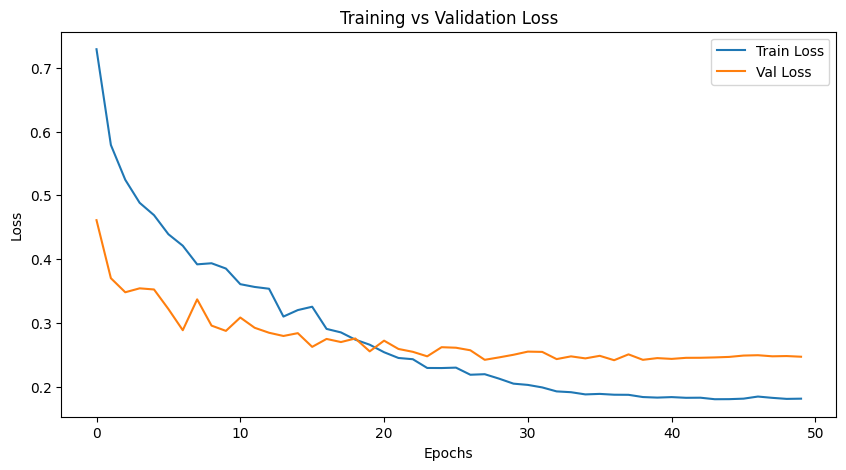


Sample Predictions:


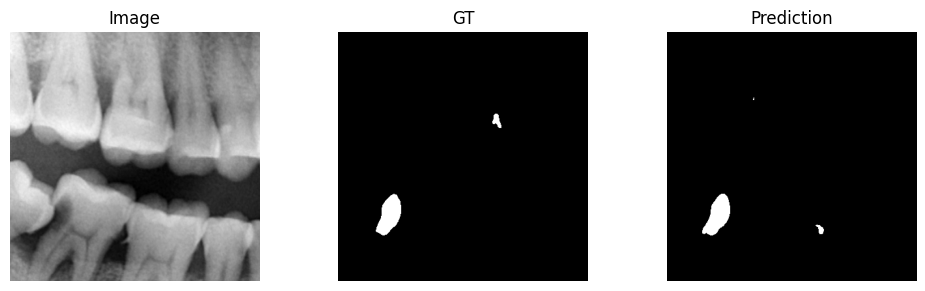

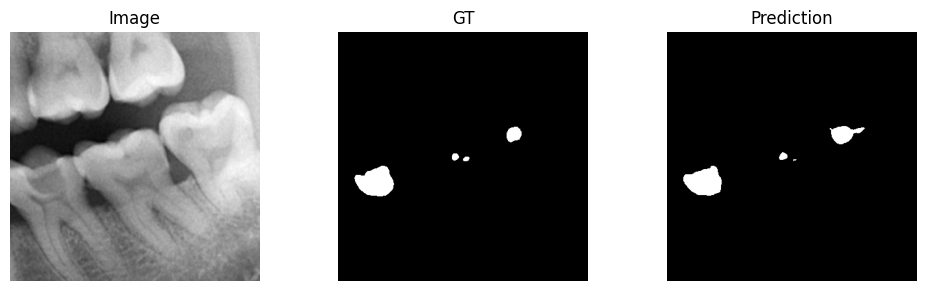

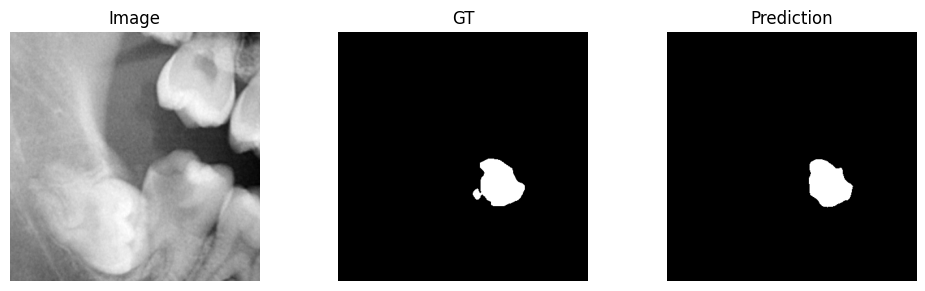

In [8]:
# =========================================================
# CELL 8 — TRAINING (FINAL CLEAN VERSION)
# =========================================================

from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger
import matplotlib.pyplot as plt
import pandas as pd
import os
from pytorch_lightning.callbacks import ModelCheckpoint

# =========================================================
# LOGGER
# =========================================================

logger = CSVLogger("logs", name="mlua")

# =========================================================
# MODEL
# =========================================================

model = MLUAModel()

# =========================================================
# TRAINER (SINGLE GPU — STABLE)
# =========================================================
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="best-model"
)

trainer = Trainer(
    max_epochs=MAX_EPOCHS,

    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,

    precision=16 if torch.cuda.is_available() else 32,

    enable_progress_bar=True,

    log_every_n_steps=50,
    check_val_every_n_epoch=1,

    logger=logger,
    enable_model_summary=True,

    callbacks=[checkpoint_callback]
)

# =========================================================
# TRAIN
# =========================================================

trainer.fit(model, train_loader, val_loader)
print(checkpoint_callback.best_model_path)
print("\nTraining Complete!")

# =========================================================
# LOSS GRAPH
# =========================================================

metrics_path = os.path.join(logger.log_dir, "metrics.csv")

if os.path.exists(metrics_path):

    df = pd.read_csv(metrics_path)

    plt.figure(figsize=(10,5))

    train_df = df.dropna(subset=["train_loss_epoch"])
    val_df   = df.dropna(subset=["val_loss"])

    plt.plot(train_df["epoch"], train_df["train_loss_epoch"], label="Train Loss")
    plt.plot(val_df["epoch"], val_df["val_loss"], label="Val Loss")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

else:
    print("Metrics file not found yet.")

# =========================================================
# VISUALIZATION
# =========================================================

def visualize_predictions(model, loader, num_samples=3, threshold=0.2):

    model.eval()
    shown = 0

    with torch.no_grad():

        for imgs, masks in loader:

            imgs = imgs.to(model.device)

            preds = torch.sigmoid(model(imgs)).cpu()

            for i in range(len(imgs)):

                img = imgs[i].cpu().squeeze()
                mask = masks[i].squeeze()
                pred = (preds[i].squeeze() > threshold)

                plt.figure(figsize=(10,3))

                plt.subplot(1,3,1)
                plt.imshow(img, cmap="gray")
                plt.title("Image")
                plt.axis("off")

                plt.subplot(1,3,2)
                plt.imshow(mask, cmap="gray")
                plt.title("GT")
                plt.axis("off")

                plt.subplot(1,3,3)
                plt.imshow(pred, cmap="gray")
                plt.title("Prediction")
                plt.axis("off")

                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return


print("\nSample Predictions:")
visualize_predictions(model, test_loader, num_samples=3)

In [9]:
# =========================================================
# CELL 9 — EVALUATION (CLEAN + RELIABLE)
# =========================================================

import numpy as np
import torch

def evaluate_model(model, loader, threshold=0.2):

    model.eval()

    dice_list = []
    iou_list = []
    sen_list = []
    spe_list = []
    acc_list = []
    pre_list = []

    with torch.no_grad():

        for imgs, masks in loader:

            imgs = imgs.to(model.device)
            masks = masks.to(model.device)

            preds = torch.sigmoid(model(imgs))
            preds = (preds > threshold).float()

            acc, iou, dice, pre, spe, sen = mean_metric(preds, masks)

            acc_list.append(acc.item())
            iou_list.append(iou.item())
            dice_list.append(dice.item())
            pre_list.append(pre.item())
            spe_list.append(spe.item())
            sen_list.append(sen.item())

    # ================= FINAL RESULTS =================
    print("\n================ FINAL RESULTS ================")
    print(f"Dice: {np.mean(dice_list):.4f}")
    print(f"IoU : {np.mean(iou_list):.4f}")
    print(f"SEN : {np.mean(sen_list):.4f}")
    print(f"SPE : {np.mean(spe_list):.4f}")
    print(f"ACC : {np.mean(acc_list):.4f}")
    print(f"PRE : {np.mean(pre_list):.4f}")

    return {
        "dice": np.mean(dice_list),
        "iou": np.mean(iou_list),
        "sen": np.mean(sen_list),
        "spe": np.mean(spe_list),
        "acc": np.mean(acc_list),
        "pre": np.mean(pre_list),
    }


# =========================================================
# RUN EVALUATION
# =========================================================

fin_metrics = evaluate_model(model, val_loader)


================ FINAL RESULTS ================
Dice: 0.6481
IoU : 0.5395
SEN : 0.7123
SPE : 0.9961
ACC : 0.9926
PRE : 0.6489
